In [ ]:
# import packages
from tifffile import TiffFile
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import cupy as cp
import pickle
import types
import os
import scipy
import psutil
import itertools
import re
import skimage

# from concurrent.futures import ThreadPoolExecutor  
# from multiprocessing import Pool 
import seaborn as sns
import scanpy as sc

import importlib

sc.set_figure_params(dpi=80)

# %load_ext line_profiler # only needed for profiling functions

In [ ]:
import cupy
import cuml
import cugraph
import cudf

In [ ]:
import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize


In [ ]:
import importlib.util
import sys

def lazy_import(
    module_name, 
    path_to_file,
):
    spec = importlib.util.spec_from_file_location(
        module_name,
        path_to_file,
    )
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
pca_utils =  lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
plotting_functions =  lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
anndata_utils =  lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
imaging_utils =  lazy_import("imaging_utils",os.path.join(utils_dir, "imaging_utils.py"))

from preprocessing_utils import kneepoint, process_pca_results, process_pca_inflection
from general_utils import ismember, write_object, read_object, flatten, grep, grep_exclude
from plotting_functions import plot_individual_category
from anndata_utils import marker_genes_for_cell_group, get_gene, filter_coordinates, query_region, random_adata_subset, zscore_with_subset
from imaging_utils import imnormalize, imblend, im2rgb, imoverlay


In [ ]:
def knn_gpu(mat, k=30):
    X_mat = cupy.array(mat)
    model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
    model.fit(X_mat)
    distances, indices = model.kneighbors(X_mat)
    return(distances, indices)

def get_cugraph_from_array(mat):
    targets = np.ravel(mat)
    n_neighbors_per_cell = [len(x) for x in mat]
    sources = np.ravel([[i]*k for i,k in zip(range(mat.shape[0]), n_neighbors_per_cell)])
    edges = cudf.concat([
        cudf.Series(sources, name='source'), # sources
        cudf.Series(targets, name='destination'), # targets
    ], axis=1)
    G = cugraph.from_cudf_edgelist(edges)
    return(G, edges)

def phenograph_gpu(indices, resolution = 1.0):
    G, edges = get_cugraph_from_array(indices)
    jaccard_edges = cugraph.jaccard(G, edges[['source', 'destination']])
    G_jaccard = cugraph.from_cudf_edgelist(jaccard_edges, *jaccard_edges.columns)
    resolution = resolution
    result, score = cugraph.leiden(G, resolution = resolution)
    # Sort clusters by size
    min_size = 0
    sizes = result['partition'].value_counts()
    sizes.loc[:] = cp.where(sizes > min_size, cp.arange(len(sizes)), -1)
    result['partition'] = result['partition'].map(sizes)
    # Sort by vertex (e.g. cell)
    clusters = result.sort_values('vertex')['partition'].values.get()
    return(clusters)

Define feature set

In [ ]:
valid_markers = [
    'DAPI_nucleus_mean_intensity', 'dpERK_cyto_mean_intensity','dpERK_nucleus_mean_intensity', 'MSN_cyto_mean_intensity','HMGA2_nucleus_mean_intensity',
    'LGALS4_cyto_mean_intensity','LGALS4_nucleus_mean_intensity','E-cadherin_cyto_mean_intensity', 'GFP_cyto_mean_intensity',
    'GFP_nucleus_mean_intensity','ANXA10_cyto_mean_intensity','ANXA10_nucleus_mean_intensity','VIM_cyto_mean_intensity',
    'VIM_nucleus_mean_intensity','p19_nucleus_intensity_ratio', 'p19_nucleus_mean_intensity', 'CC3_cyto_mean_intensity',
    'CC3_nucleus_mean_intensity', 'CPA1_nucleus_mean_intensity', 'CPA1_cyto_mean_intensity']

valid_markers = [
    'DAPI_nucleus_mean_intensity', 'MSN_cyto_mean_intensity','HMGA2_nucleus_mean_intensity',
    'LGALS4_cyto_mean_intensity','LGALS4_nucleus_mean_intensity','E-cadherin_cyto_mean_intensity', 'GFP_cyto_mean_intensity',
    'GFP_nucleus_mean_intensity','ANXA10_cyto_mean_intensity','ANXA10_nucleus_mean_intensity','p19_nucleus_intensity_ratio', 'p19_nucleus_mean_intensity', 'CC3_cyto_mean_intensity',
    'CC3_nucleus_mean_intensity', 'CPA1_nucleus_mean_intensity', 'CPA1_cyto_mean_intensity']

valid_markers_reduced = [
    'DAPI_nucleus_mean_intensity', 'dpERK_nucleus_mean_intensity', 'CPA1_nucleus_mean_intensity', 'E-cadherin_cyto_mean_intensity', 'GFP_cyto_mean_intensity',
    'p19_nucleus_intensity_ratio', 'MSN_cyto_mean_intensity','HMGA2_nucleus_mean_intensity',
    'LGALS4_cyto_mean_intensity','ANXA10_nucleus_mean_intensity','VIM_cyto_mean_intensity']

### Analyze batch of slides

In [ ]:
rawdatapath = "../preprocessed"
np.sort(os.listdir(rawdatapath))

In [ ]:
selected_slides = ['JR-sp-15-010', 'JR-sp-15-011']
result = []
for my_slide in selected_slides:
    result.append(sc.read_h5ad(os.path.join(rawdatapath, "Reyes_COMET_adata_epi_" + my_slide + ".h5ad")))
adata = sc.concat(result, axis = 0)

In [ ]:
adata_sub = adata.copy()
adata_sub.X = adata_sub.layers['raw'].copy()
sc.pp.log1p(adata_sub)
sc.pp.scale(adata_sub)

adata_sub.var['valid_markers'] = ismember(adata_sub.var_names, valid_markers)[1]

sc.pp.pca(adata_sub, mask_var='valid_markers', n_comps=np.sum(adata_sub.var['valid_markers']) - 1)
adata_sub.uns['pca_explained_variance'] = adata_sub.uns['pca']['variance_ratio']

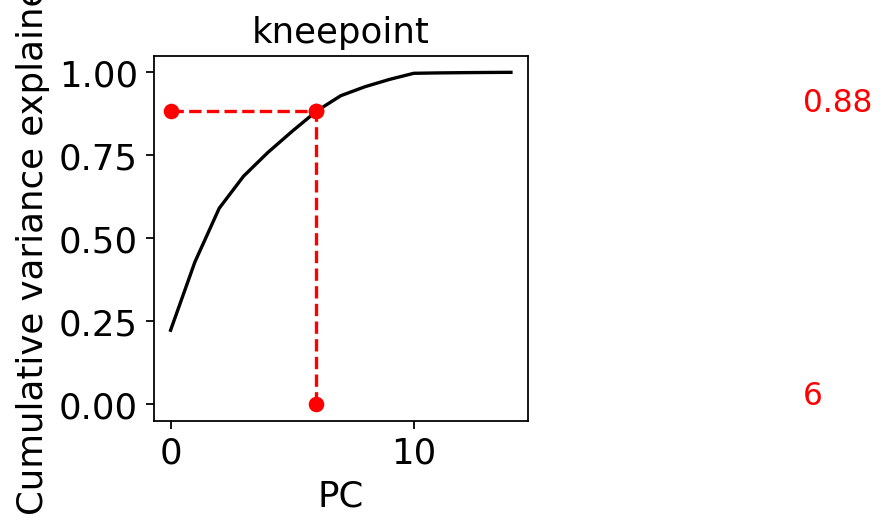

In [ ]:
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = 'kneepoint', min_pcs = 1)
adata_sub.obsm['X_pca'] = adata_sub.obsm['X_pca'][:,:selected_pcs].copy()

In [ ]:
distances, indices = knn_gpu(adata_sub.obsm['X_pca'])
adata_sub.obs['pheno_30'] = phenograph_gpu(indices)
adata_sub.obs['pheno_30'] = pd.Categorical(adata_sub.obs['pheno_30'])

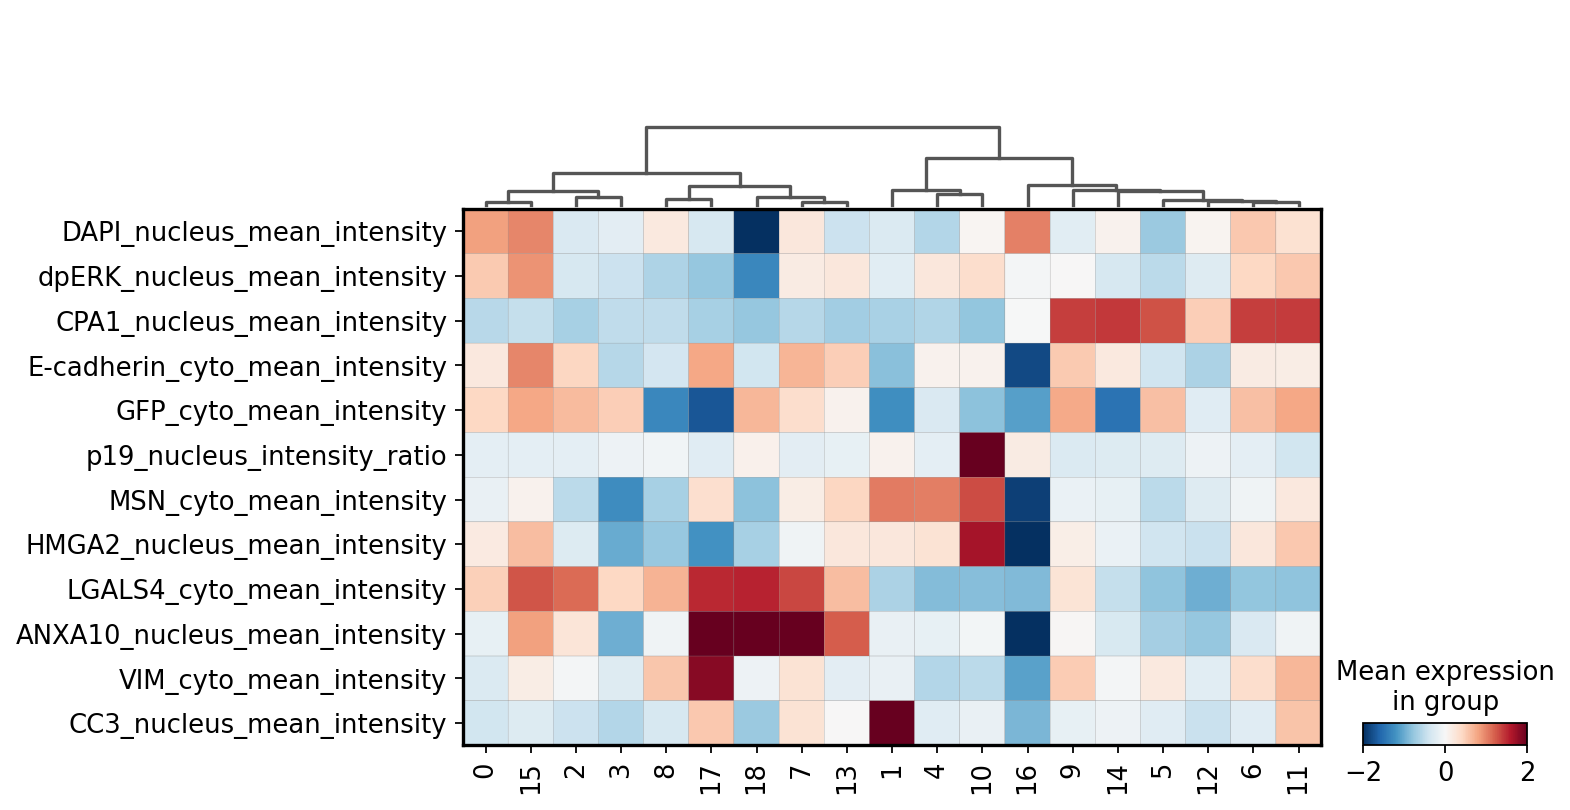

In [ ]:
sc.tl.dendrogram(adata_sub, groupby = 'pheno_30', var_names = valid_markers_reduced, linkage_method = "ward")
sc.pl.matrixplot(adata_sub, groupby = 'pheno_30', var_names = valid_markers_reduced, dendrogram=True, vmin = -2, vmax = 2, cmap='RdBu_r', swap_axes = True)


In [ ]:
cell_type_1 = np.array(['other'] * adata_sub.n_obs, dtype = object)
cell_type_1[ismember(adata_sub.obs['pheno_30'], [9,14,5,12,6,11])[1]] = 'adm'
cell_type_1[ismember(adata_sub.obs['pheno_30'], [0,2,3,8])[1]] = 'gastric_lgals4'
cell_type_1[ismember(adata_sub.obs['pheno_30'], [15,17,18,7,13])[1]] = 'gastric_anxa10'
cell_type_1[ismember(adata_sub.obs['pheno_30'], [1,4])[1]] = 'progenitor_msn'
cell_type_1[ismember(adata_sub.obs['pheno_30'], [10])[1]] = 'progenitor_hmga2'

cell_type_0 = np.array(['other'] * adata_sub.n_obs, dtype = object)
cell_type_0[ismember(cell_type_1, ["adm"])[1]] = "adm"
cell_type_0[ismember(cell_type_1, ["gastric_lgals4", "gastric_anxa10"])[1]] = "gastric"
cell_type_0[ismember(cell_type_1, ["gastricprogenitor"])[1]] = "gastricprogenitor"
cell_type_0[ismember(cell_type_1, ["progenitor_msn", "progenitor_hmga2"])[1]] = "progenitor"


In [ ]:
adata_sub.obs['cell_type_0'] = cell_type_0.copy()
adata_sub.obs['cell_type_1'] = cell_type_1.copy()

if 'cell_type_0_colors' in adata_sub.uns:
    del adata_sub.uns['cell_type_0_colors']
if 'cell_type_1_colors' in adata_sub.uns:
    del adata_sub.uns['cell_type_1_colors']

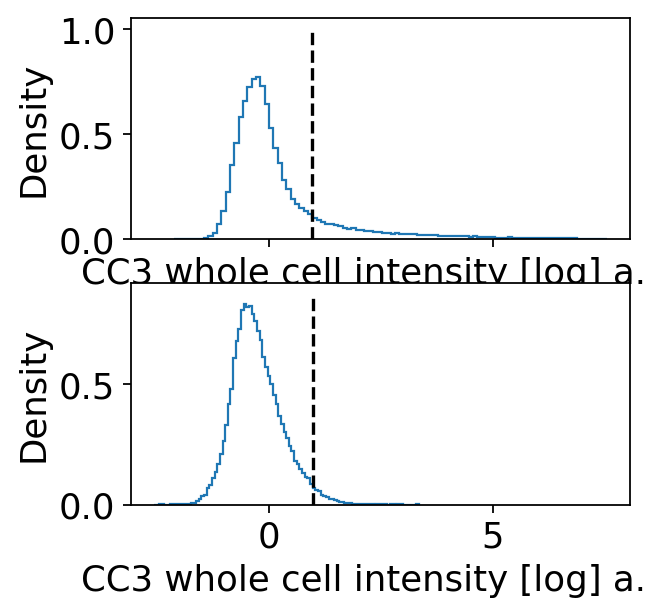

In [ ]:
all_thresholds = dict()
f, ax = plt.subplots(len(selected_slides), 1, sharex = True)

cc3_positive = np.array([False] * adata_sub.n_obs, dtype = bool)
for i, my_slide in enumerate(selected_slides):
    subcells = adata_sub.obs['slide_id'] == my_slide
    cc3_signal = get_gene(adata_sub[subcells], "CC3_cyto_mean_intensity")
    h, bins = np.histogram(cc3_signal, bins = 100, density = True)
    ax[i].stairs(h, bins)
    threshold = threshold_triangle([h, bins])
    ax[i].plot([threshold]*2, plt.gca().get_ylim(), "k--")
    ax[i].set_xlabel("CC3 whole cell intensity [log] a.u.")
    ax[i].set_ylabel("Density")
    all_thresholds[my_slide] = threshold
    cc3_positive[subcells] = cc3_signal >= threshold
adata_sub.obs['cc3_positive'] = cc3_positive

In [ ]:
obs_path = "../obs"
os.makedirs(obs_path, exist_ok=True)
adata_sub.obs.to_csv(os.path.join(obs_path, "JR-sp-15_batch1.csv.gz"))